# E-commerce Analytics Project
End-to-end analysis using SQL + Python


In [ ]:
import pandas as pd
customers = pd.read_csv('/content/customers.csv')
products = pd.read_csv('/content/products.csv')
orders = pd.read_csv('/content/orders.csv')
returns = pd.read_csv('/content/returns.csv')
customers.head()

,customer_id,city,signup_date
0,1,Cologne,2023-02-25
1,2,Berlin,2023-07-15
2,3,Berlin,2023-01-20
3,4,Cologne,2023-08-29
4,5,Hamburg,2023-04-24


In [ ]:
!pip install pandasql

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=dc3c4c093985be377dea6de96a8b88435a58a81fc01ee1941f6bf78d889e154f
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


In [ ]:
from pandasql import sqldf
q = lambda x: sqldf(x, globals())

## SQL Analysis

In [ ]:
# Revenue by category
q('''
SELECT p.category, SUM(o.total_amount) AS revenue
FROM orders o
JOIN products p ON o.product_id = p.product_id
GROUP BY p.category
ORDER BY revenue DESC
''')

,category,revenue
0,Home,320907.31
1,Clothing,315413.07
2,Electronics,296997.27
3,Sports,208177.86


Top category: Home
It contributes highest revenue and
Business is heavily dependent on this category.

In [ ]:
# Customer Lifetime Value
q('''
SELECT customer_id, SUM(total_amount) AS lifetime_value
FROM orders
GROUP BY customer_id
ORDER BY lifetime_value DESC
''')

,customer_id,lifetime_value
0,56,7172.14
1,312,6950.95
2,252,6538.28
3,361,6519.07
4,362,6466.54
...,...,...
485,265,86.44
486,218,76.92
487,488,41.88
488,410,40.18


In [ ]:
# Repeat Purchase Rate
q('''
SELECT COUNT(DISTINCT customer_id) AS total_customers,
SUM(CASE WHEN order_count > 1 THEN 1 ELSE 0 END) AS repeat_customers
FROM (
SELECT customer_id, COUNT(*) AS order_count
FROM orders
GROUP BY customer_id
) t
''')

,total_customers,repeat_customers
0,490,454


## Python Analysis

In [ ]:
orders['order_date'] = pd.to_datetime(orders['order_date'])

In [ ]:
# RFM
rfm = orders.groupby('customer_id').agg({
    'order_date': 'max',
    'order_id': 'count',
    'total_amount': 'sum'
}).reset_index()
rfm.columns = ['customer_id', 'last_purchase', 'frequency', 'monetary']
today = orders['order_date'].max()
rfm['recency'] = (today - rfm['last_purchase']).dt.days
rfm.head()

,customer_id,last_purchase,frequency,monetary,recency
0,1,2024-02-12,5,3150.46,323
1,2,2024-11-27,2,942.84,34
2,3,2024-08-08,5,2147.15,145
3,4,2024-12-15,4,1095.97,16
4,5,2024-09-13,4,1898.50,109


In [ ]:
# Segmentation
from sklearn.cluster import KMeans
X = rfm[['recency','frequency','monetary']]
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['segment'] = kmeans.fit_predict(X)
rfm.head()

,customer_id,last_purchase,frequency,monetary,recency,segment
0,1,2024-02-12,5,3150.46,323,0
1,2,2024-11-27,2,942.84,34,2
2,3,2024-08-08,5,2147.15,145,0
3,4,2024-12-15,4,1095.97,16,2
4,5,2024-09-13,4,1898.50,109,0


In [ ]:
# Segment summary
rfm.groupby('segment').agg({'recency':'mean','frequency':'mean','monetary':'mean'})

,recency,frequency,monetary
segment,,,
0,99.694915,4.423729,2484.344294
1,75.242424,7.000000,5605.884545
2,172.570000,2.700000,1005.354050
3,74.262500,5.575000,3946.269625


Segment 0:
Recency ~100 days, frequency ~4.4, monetary ~2484  
→ Medium recency, good frequency, high spend  
→ Regular customers (valuable but not most active)

Segment 1:
Recency ~75 days, frequency ~7, monetary ~5605  
→ Low recency, very high frequency, highest spend  
→ Loyal / high-value customers (best segment)

Segment 2:
Recency ~172 days, frequency ~2.7, monetary ~1005  
→ High recency (inactive), low frequency, low spend  
→ Churn risk / low-value customers

Segment 3:
Recency ~74 days, frequency ~5.5, monetary ~3946  
→ Low recency, good frequency, high spend  
→ Potential loyal customers (can be converted to top segment)

In [ ]:
# Churn
rfm['churn'] = rfm['recency'] > 90
rfm['churn'].value_counts()

,count
churn,
False,250
True,240


490 total customers analyzed.

240 customers (≈49%) have churned (no purchase in last 90 days).  
250 customers (≈51%) are active.

Churn rate is high, indicating a need for retention strategies.

<Axes: xlabel='month'>

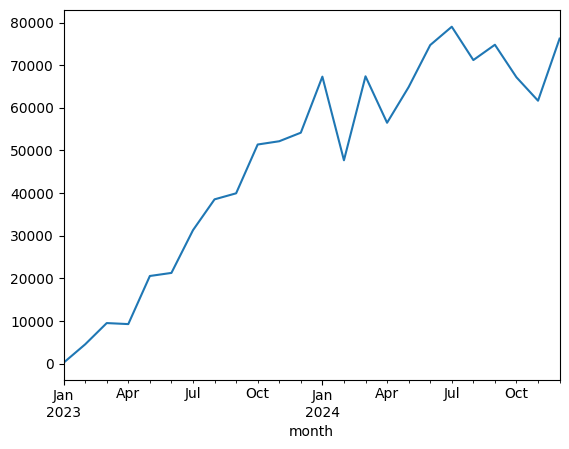

In [ ]:
# Sales Trend
orders['month'] = orders['order_date'].dt.to_period('M')
monthly = orders.groupby('month')['total_amount'].sum()
monthly.plot()

Sales peak during July and December months -> seasonal demand.
Sales drop in Jan till April -> low activity period.

In [ ]:
# Return Rate
returns_merged = returns.merge(orders, on='order_id').merge(products, on='product_id')
total_orders = orders.merge(products, on='product_id')
returns_count = returns_merged.groupby('category').size()
total_count = total_orders.groupby('category').size()
return_rate = (returns_count / total_count).fillna(0)
return_rate

,0
category,
Clothing,0.114625
Electronics,0.085258
Home,0.111801
Sports,0.089286


Clothing Category has highest return rate.
Possible issue with product quality or expectations.

FINAL INSIGHTS:

- Top revenue driver: Home category
- Loyal customer segment identified as Segment 1
- Churn rate: 49%
- High return category: Clothing
- Seasonal demand observed in July and December months